### Week 6 — Visualization of Metrics and Graphs

#### Aim - To visualize the performance of the cardiovascular disease prediction models using different graphs and performance metrics.

**1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

**2. Load Dataset**

In [2]:
df = pd.read_csv("C:/Users/SMART/OneDrive/Desktop/ML Project/CardioDiseasePrediction/dataset/cardio_train.csv", sep=';')

**3. Prepare X and y**

In [4]:
X = df.drop(["id", "cardio"], axis=1)

y = df["cardio"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**4. Create Models**

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

**5. Calculate Performance Metrics**

In [6]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

c:\Users\SMART\OneDrive\Desktop\ML Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.710786,0.728169,0.674273,0.700185
1,Decision Tree,0.628714,0.627567,0.636338,0.631922
2,KNN,0.682071,0.688781,0.666286,0.677347
3,Random Forest,0.713000,0.718349,0.702367,0.710268
4,Gradient Boosting,0.737786,0.752761,0.709498,0.730490


**6. Accuracy Graph**

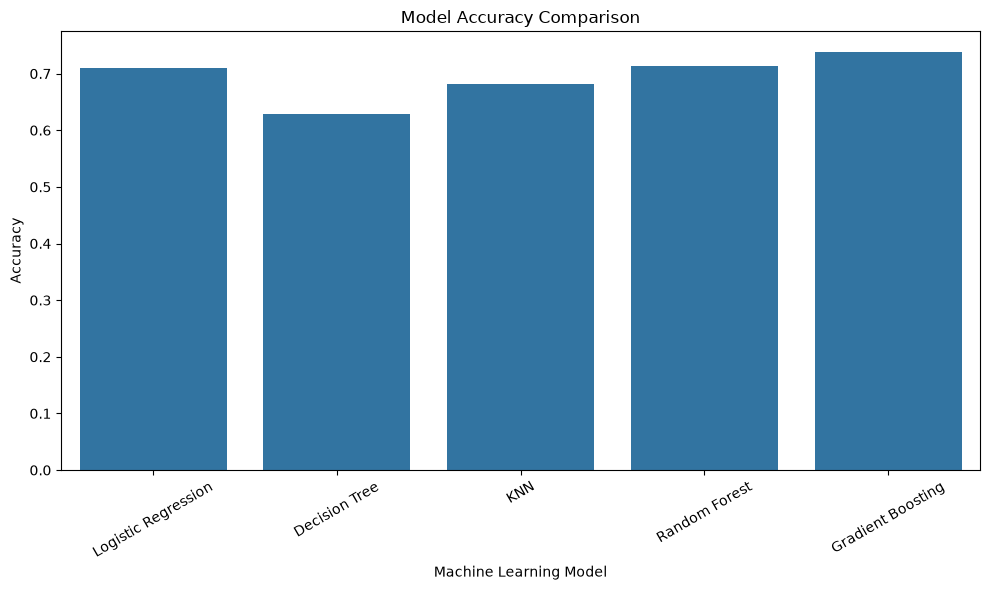

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

**7. Precision Graph**

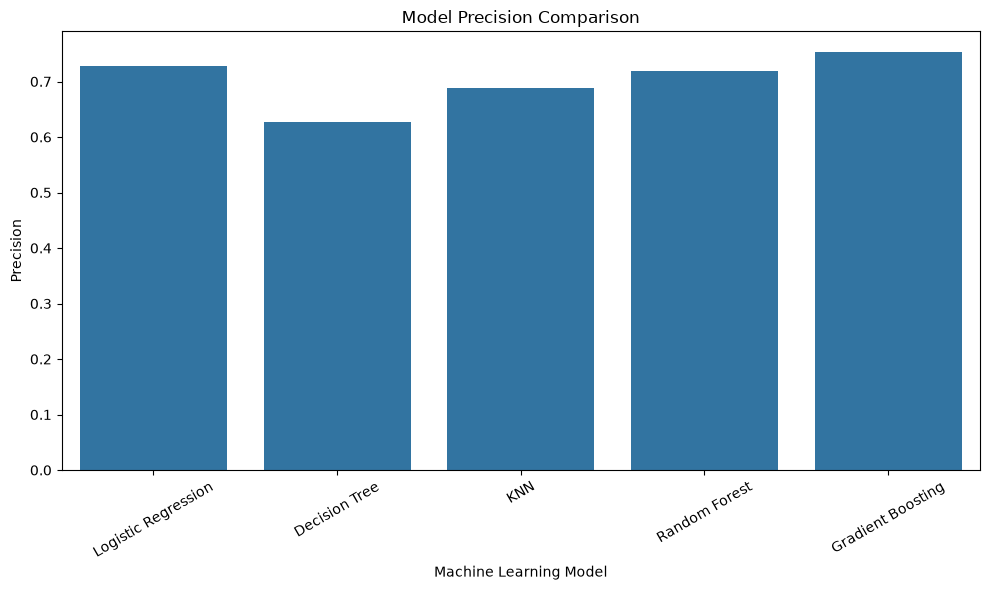

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Model",
    y="Precision",
    data=results_df
)

plt.title("Model Precision Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Precision")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

**8. Recall Graph**

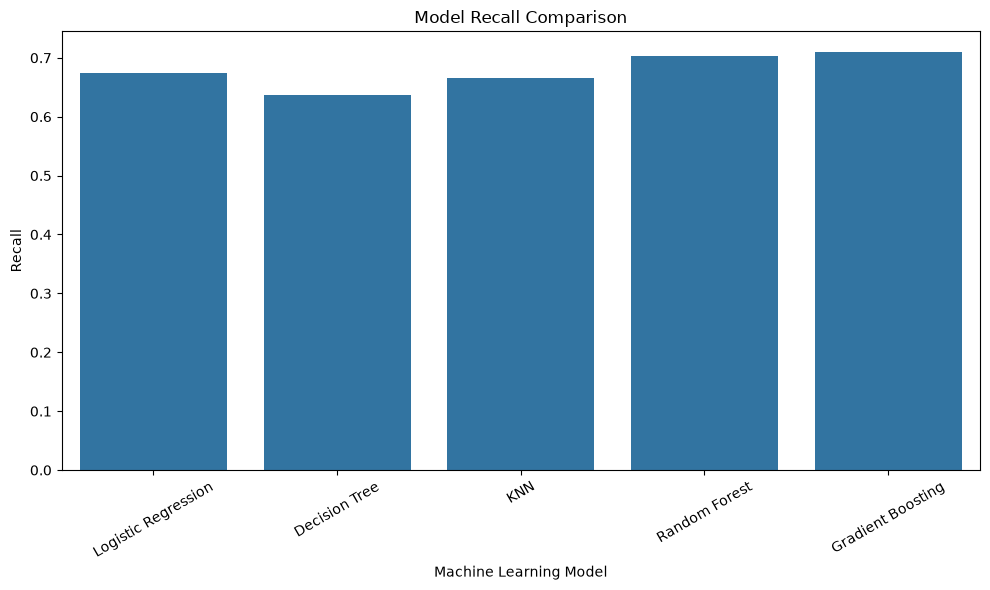

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Model",
    y="Recall",
    data=results_df
)

plt.title("Model Recall Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Recall")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

**9. F1 Score Graph**

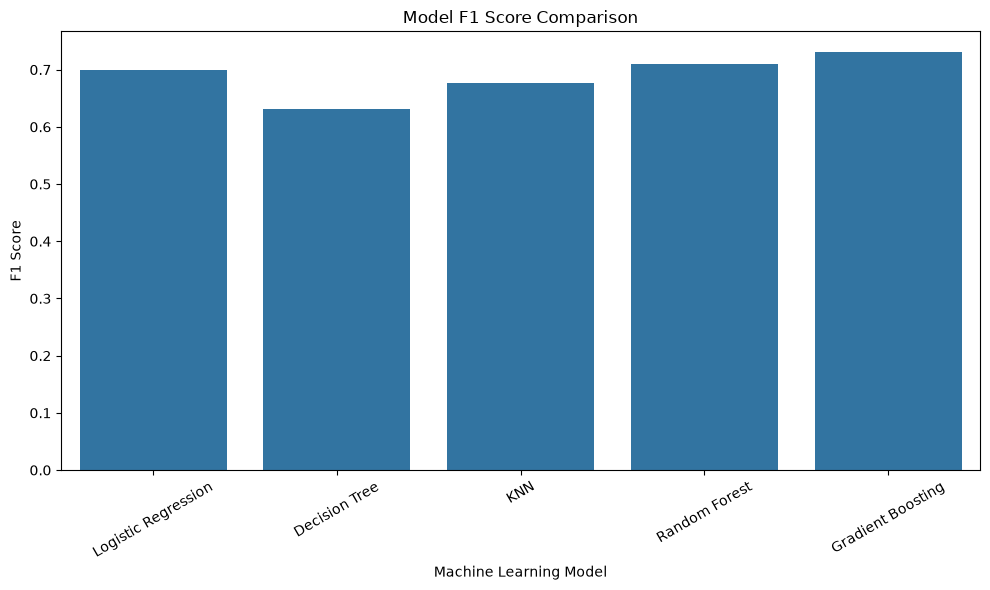

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Model",
    y="F1 Score",
    data=results_df
)

plt.title("Model F1 Score Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("F1 Score")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

**10. All Metrics Together**

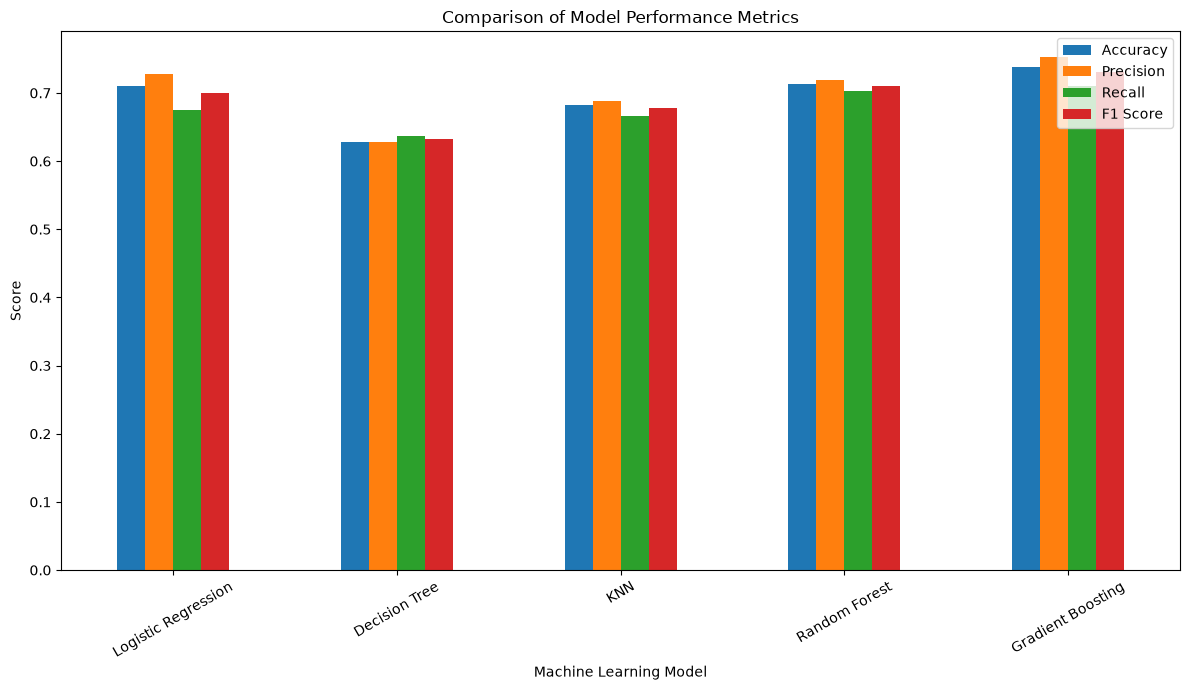

In [11]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Comparison of Model Performance Metrics")

plt.xlabel("Machine Learning Model")

plt.ylabel("Score")

plt.xticks(rotation=30)

plt.legend()

plt.tight_layout()

plt.show()

**11. Confusion Matrix**

In [13]:
best_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)

print(cm)

[[5057 1931]
 [2087 4925]]


**12. Confusion Matrix Visualization**

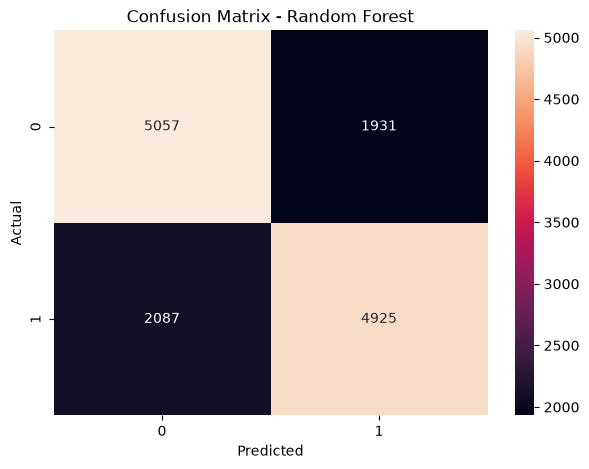

In [14]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**13. ROC Curve**

In [16]:
y_probability = best_model.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)


auc_score = roc_auc_score(
    y_test,
    y_probability
)

print("AUC Score:", auc_score)

AUC Score: 0.7739008151370894


**14. Plot ROC Curve**

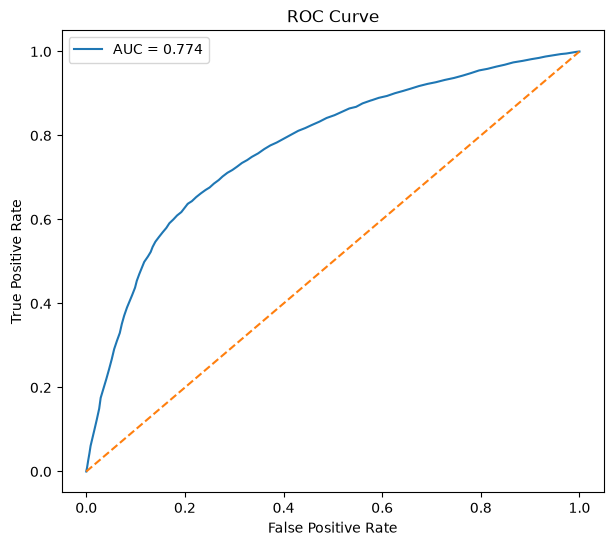

In [17]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**15. Feature Importance**

In [18]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,age,0.309179
4,ap_hi,0.175971
3,weight,0.172267
2,height,0.157043
5,ap_lo,0.087078
6,cholesterol,0.038196
7,gluc,0.016255
1,gender,0.015695
10,active,0.012888
8,smoke,0.008143


**16. Feature Importance Graph**

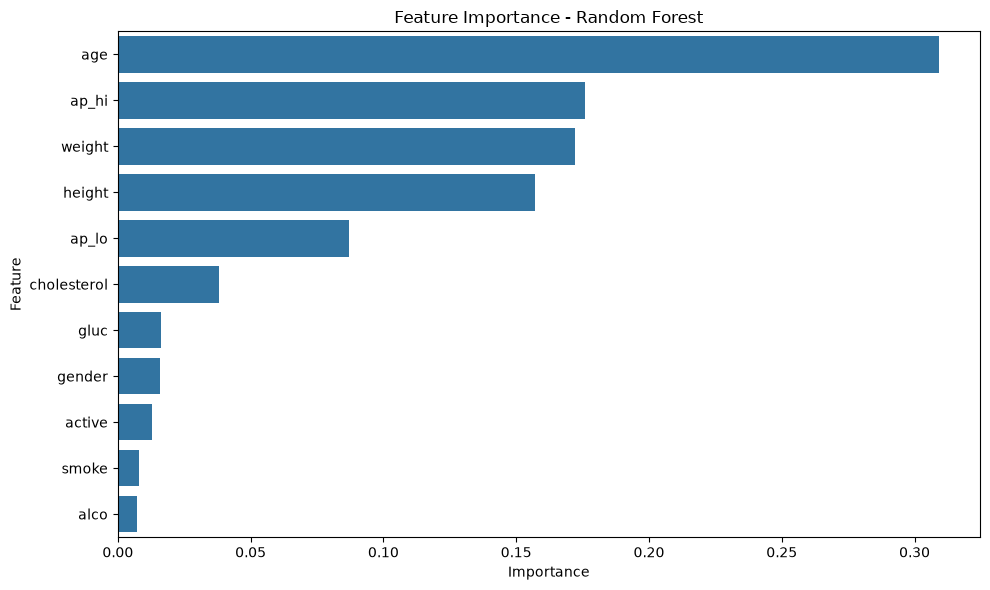

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

**17. Cross-Validation Graph**

In [21]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores.mean()
    })

cv_comparison = pd.DataFrame(cv_results)

cv_comparison

c:\Users\SMART\OneDrive\Desktop\ML Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\SMART\OneDrive\Desktop\ML Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.

,Model,CV Accuracy
0,Logistic Regression,0.705839
1,Decision Tree,0.636696
2,KNN,0.678696
3,Random Forest,0.716018
4,Gradient Boosting,0.734446


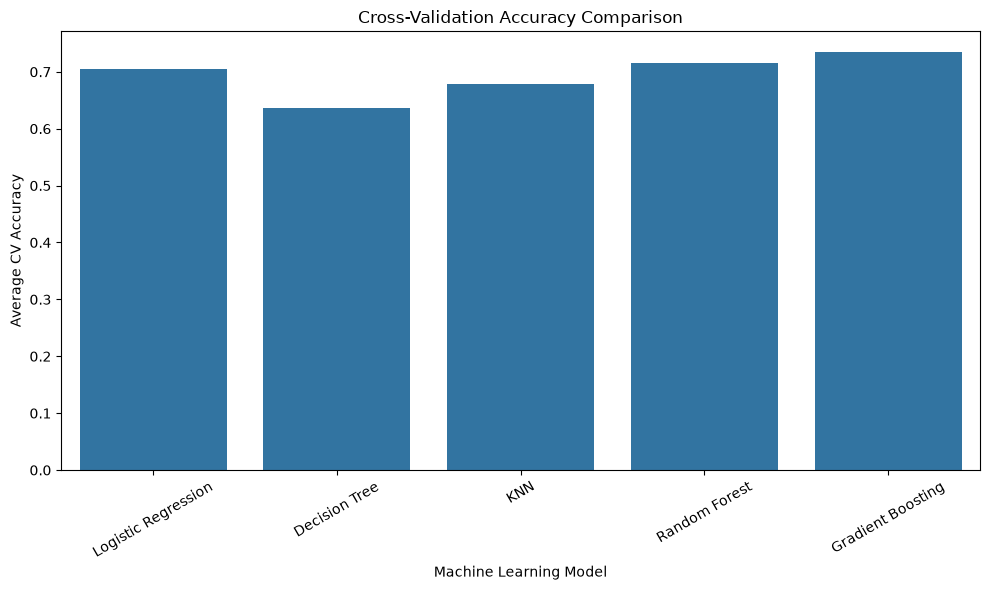

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Model",
    y="CV Accuracy",
    data=cv_comparison
)

plt.title("Cross-Validation Accuracy Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Average CV Accuracy")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()